# Normal Denklem (Normal Equation) Matematiksel Türetimi

Normal Denklem, Lineer Regresyon modelinin hata (maliyet) fonksiyonunu minimize eden $\theta$ parametrelerini doğrudan (analitik olarak) bulmamızı sağlayan kapalı form (closed-form) bir çözümdür.

Amaç, aşağıdaki hata fonksiyonunu minimize eden $\theta$ değerini bulmaktır.

---

## 1. Hata Fonksiyonunun Matris Formunda Yazılması

Ortalama Kare Hata (MSE) fonksiyonumuz:
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Bu ifadeyi vektör ve matris gösterimiyle yazalım. 
* $X$ eğitim verisi matrisi ($m \times (n+1)$ boyutunda)
* $y$ hedef etiket vektörü ($m \times 1$ boyutunda)
* $\theta$ parametre vektörü ($(n+1) \times 1$ boyutunda)

Bu durumda tahmin vektörü $\hat{y} = X\theta$ olur. Hata (residual) vektörü ise $X\theta - y$ şeklindedir. Bir vektörün kendisiyle nokta çarpımı, elemanlarının kareleri toplamını verir. Dolayısıyla:

$$J(\theta) = \frac{1}{m} (X\theta - y)^T (X\theta - y)$$

---

## 2. Matris Çarpımının Dağıtılması

Parantezleri transpoze kurallarına göre açalım ($(A - B)^T = A^T - B^T$):

$$J(\theta) = \frac{1}{m} \left( (X\theta)^T - y^T \right) (X\theta - y)$$
$$J(\theta) = \frac{1}{m} \left( \theta^T X^T - y^T \right) (X\theta - y)$$

Şimdi çarpma işlemini dağıtalım:

$$J(\theta) = \frac{1}{m} \left( \theta^T X^T X \theta - \theta^T X^T y - y^T X \theta + y^T y \right)$$

### Önemli Not (Transpoze Eşitliği):
Buradaki $\theta^T X^T y$ ve $y^T X \theta$ terimlerinin her ikisi de nihayetinde **skaler (tek bir sayı)** değer üretir. Bir skalerin transpozesi kendisine eşittir:
$$(\theta^T X^T y)^T = y^T (X^T)^T (\theta^T)^T = y^T X \theta$$

Bu iki terim birbirine eşit olduğu için bunları birleştirebiliriz:

$$J(\theta) = \frac{1}{m} \left( \theta^T X^T X \theta - 2\theta^T X^T y + y^T y \right)$$

---

## 3. Türev Alma ve Sıfıra Eşitleme

Fonksiyonu minimize etmek için $\theta$'ya göre kısmi türevini alır ve sıfıra eşitleriz ($\frac{\partial J(\theta)}{\partial \theta} = 0$).

Matris kalkülüsündeki temel türev kuralları:
1. $\frac{\partial}{\partial \theta} (\theta^T A) = A$
2. $\frac{\partial}{\partial \theta} (\theta^T A \theta) = 2 A \theta$ (eğer $A$ simetrik bir matris ise - ki $X^T X$ simetriktir)

Bu kuralları formülümüze uygulayalım ($y^T y$ teriminde $\theta$ olmadığı için türevi $0$ olur):

$$\frac{\partial J(\theta)}{\partial \theta} = \frac{1}{m} \left( 2 X^T X \theta - 2 X^T y \right) = 0$$

---

## 4. $\theta$'yı Yalnız Bırakma (Sonuç)

Türev sonucunu sıfıra eşitleyip sadeleştirelim:

$$2 X^T X \theta - 2 X^T y = 0$$
$$X^T X \theta = X^T y$$

Eşitliğin her iki yanını soldan $(X^T X)^{-1}$ (matrisin tersi) ile çarpalım:

$$(X^T X)^{-1} (X^T X) \theta = (X^T X)^{-1} X^T y$$

Bir matrisin tersiyle kendisinin çarpımı birim matrisi ($I$) verir ($I\theta = \theta$):

$$\theta = (X^T X)^{-1} X^T y$$

İşte bu, hedeflediğimiz **Normal Denklem** formülüdür!


# Adım Adım Sayısal Örnek Hesaplama

Normal Denklemin matris operasyonlarını daha iyi kavramak için küçük bir veri kümesi üzerinden elle hesaplama yapalım.

## Veri Kümemiz
3 adet veri noktamız ($m = 3$) ve 1 adet özelliğimiz ($n = 1$) olsun:

| Örnek ($i$) | Özellik ($x$) | Hedef ($y$) |
| :--- | :--- | :--- |
| 1 | 1 | 2 |
| 2 | 2 | 3 |
| 3 | 3 | 5 |

Amacımız, bu noktalardan geçen en uygun doğruyu ($\hat{y} = \theta_0 + \theta_1 x$) bulmaktır.

---

## Adım 1: Matrisleri Oluşturma

Bias terimi ($\theta_0$) için veri matrisimize birinci sütun olarak $1$ değerlerini ekleriz ($x_0 = 1$):

$$X = \begin{bmatrix} 1 & 1 \\ 1 & 2 \\ 1 & 3 \end{bmatrix}, \quad y = \begin{bmatrix} 2 \\ 3 \\ 5 \end{bmatrix}$$

---

## Adım 2: $X$ Matrisinin Transpozesini Alın ($X^T$)

$$X^T = \begin{bmatrix} 1 & 1 & 1 \\ 1 & 2 & 3 \end{bmatrix}$$

---

## Adım 3: $X^T X$ Çarpımını Hesaplayın

$$X^T X = \begin{bmatrix} 1 & 1 & 1 \\ 1 & 2 & 3 \end{bmatrix} \begin{bmatrix} 1 & 1 \\ 1 & 2 \\ 1 & 3 \end{bmatrix}$$

Çarpım matrisinin her bir elemanını hesaplayalım:
* Satır 1, Sütun 1: $1(1) + 1(1) + 1(1) = 3$
* Satır 1, Sütun 2: $1(1) + 1(2) + 1(3) = 6$
* Satır 2, Sütun 1: $1(1) + 2(1) + 3(1) = 6$
* Satır 2, Sütun 2: $1(1) + 2(2) + 3(3) = 1 + 4 + 9 = 14$

Sonuç:
$$X^T X = \begin{bmatrix} 3 & 6 \\ 6 & 14 \end{bmatrix}$$

---

## Adım 4: $X^T X$ Matrisinin Tersini Hesaplayın ($(X^T X)^{-1}$)

$2 \times 2$ boyutunda bir matrisin tersini alma formülü:
$$\begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1} = \frac{1}{ad - bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

Bizim matrisimiz için determinant ($ad - bc$):
$$\text{det} = 3(14) - 6(6) = 42 - 36 = 6$$

Şimdi matrisin tersini bulalım:
$$(X^T X)^{-1} = \frac{1}{6} \begin{bmatrix} 14 & -6 \\ -6 & 3 \end{bmatrix} = \begin{bmatrix} 14/6 & -6/6 \\ -6/6 & 3/6 \end{bmatrix} = \begin{bmatrix} \frac{7}{3} & -1 \\ -1 & \frac{1}{2} \end{bmatrix}$$

---

## Adım 5: $X^T y$ Çarpımını Hesaplayın

$$X^T y = \begin{bmatrix} 1 & 1 & 1 \\ 1 & 2 & 3 \end{bmatrix} \begin{bmatrix} 2 \\ 3 \\ 5 \end{bmatrix}$$

* Satır 1: $1(2) + 1(3) + 1(5) = 10$
* Satır 2: $1(2) + 2(3) + 3(5) = 2 + 6 + 15 = 23$

Sonuç:
$$X^T y = \begin{bmatrix} 10 \\ 23 \end{bmatrix}$$

---

## Adım 6: $\theta$ Parametrelerini Hesaplayın ($\theta = (X^T X)^{-1} X^T y$)

$$\theta = \begin{bmatrix} \frac{7}{3} & -1 \\ -1 & \frac{1}{2} \end{bmatrix} \begin{bmatrix} 10 \\ 23 \end{bmatrix}$$

* $\theta_0$ (Bias): $\frac{7}{3}(10) + (-1)(23) = \frac{70}{3} - 23 = \frac{70 - 69}{3} = \frac{1}{3} \approx 0.333$
* $\theta_1$ (Eğim/Ağırlık): $(-1)(10) + \frac{1}{2}(23) = -10 + 11.5 = 1.5 = \frac{3}{2}$

Sonuç Parametre Vektörümüz:
$$\theta = \begin{bmatrix} 0.333 \\ 1.5 \end{bmatrix}$$

---

## Sonuç ve Doğrulama

Bulduğumuz modele göre en uygun doğrumuz: **$\hat{y} = 0.333 + 1.5 x$**

Tahminlerimizi kontrol edelim:
* $x = 1$ için: $\hat{y} = 0.333 + 1.5(1) = 1.833$ (Gerçek değer $2$ idi)
* $x = 2$ için: $\hat{y} = 0.333 + 1.5(2) = 3.333$ (Gerçek değer $3$ idi)
* $x = 3$ için: $\hat{y} = 0.333 + 1.5(3) = 4.833$ (Gerçek değer $5$ idi)

Gördüğünüz gibi, Normal Denklem hiçbir döngü (iterasyon) veya Gradient Descent algoritması kullanmadan, hata kareler toplamını minimize eden en uygun $\theta$ değerlerini tek seferde analitik olarak buldu!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

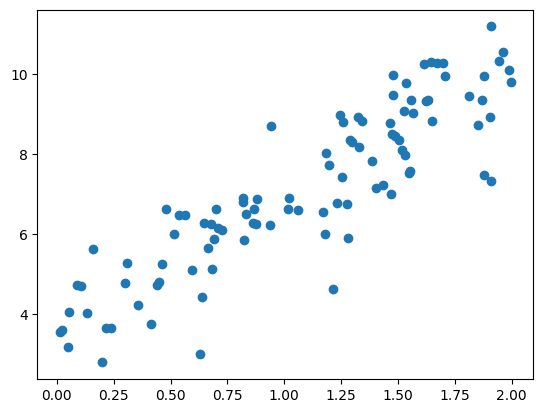

In [3]:

X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

plt.scatter(X ,y)

In [4]:
X_b = np.c_[np.ones((100, 1)), X]   # add x0 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [5]:
theta_best

array([[3.63150676],
       [3.22846055]])

In [6]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new]      # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 3.63150676],
       [10.08842785]])

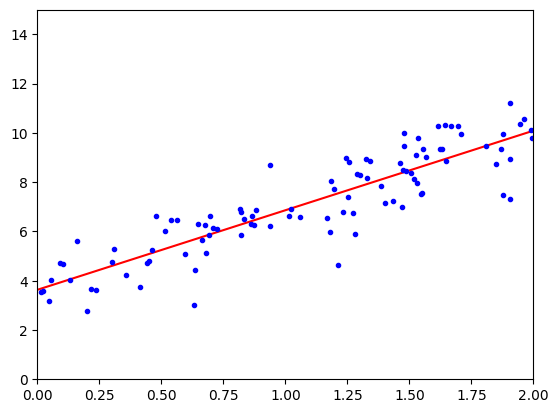

In [7]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()